In [2]:
# ---- Diagnostic: January wind-infeasibility root cause ----
# Sweeps C_AW across the ITTC-consistent calibration band (target ratios
# 0.15 / 0.20 / 0.25 at Hs=3m/Tp=9s/head/service-speed) and checks whether
# the wind-inclusive DP is feasible under DEADLINE_H, for both Jan and Jul.
# All C_AW variants below are LOCAL to this cell -- src/ is untouched.

import pandas as pd
from scipy.optimize import brentq

from src.models.ship import SHIP
from src.models.engine import Engine, SMCR_KW
from src.models.propeller import T_FRAC
from src.models.waves import added_resistance_waves, C_AW_CALIBRATED, TARGET_RATIO_AT_HS3
from src.models.resistance import R_calm_cond, thrust_from_prop, torque_from_prop, R_wind
from src.optimizer.dp import run_dp_optimizer, compute_deadline_h
from src.optimizer.leg_cost import RPM_CANDIDATES, BALLAST_CONDITION, leg_weather, leg_wind
from src.data.era5 import load_era5, extract_route_weather
from src.database.connection import get_connection
from src.database.queries import get_route_legs

_ENGINE = Engine('ISO')
ETA_SHAFT = 0.98


# --- local, C_AW-explicit versions (diagnostic only, not src/) ---

def _solve_equilibrium_speed_cond_diag(rpm, Hs, Tp, wave_dir, heading, ballast, C_AW,
                                        u10=0.0, v10=0.0, t=T_FRAC, V_range=(0.5, 25.0)):
    def imbalance(V_ms):
        V_kn = V_ms / 0.514444
        R_total = (R_calm_cond(V_ms, ballast)
                   + added_resistance_waves(Hs, Tp, V_kn, wave_dir, heading, C_AW=C_AW)
                   + R_wind(u10, v10, V_kn, heading, ballast))
        return thrust_from_prop(V_ms, rpm) * (1 - t) - R_total
    lo, hi = V_range
    if imbalance(lo) * imbalance(hi) > 0:
        return None
    return brentq(imbalance, lo, hi, xtol=1e-4)


def _fuel_rate_diag(rpm, Hs, Tp, wave_dir, heading, ballast, C_AW, u10=0.0, v10=0.0):
    V_eq = _solve_equilibrium_speed_cond_diag(rpm, Hs, Tp, wave_dir, heading, ballast, C_AW, u10, v10)
    if V_eq is None:
        return None, None
    Q = torque_from_prop(V_eq, rpm)
    P_brake_kw = Q * (rpm * 2 * 3.141592653589793 / 60.0) / ETA_SHAFT / 1000.0
    load_pct = 100 * P_brake_kw / SMCR_KW
    load_clamped = max(_ENGINE.load_pct.min(), min(_ENGINE.load_pct.max(), load_pct))
    sfoc = float(_ENGINE.sfoc_of_load(load_clamped))
    return V_eq / 0.514444, sfoc * P_brake_kw / 1e6 * 1000.0  # kg/h


def _build_cost_table_diag(legs, summary, month_period, ballast, C_AW, include_wind):
    rows = []
    for leg_id in legs['leg_id']:
        dist_nm = legs.loc[leg_id, 'dist_nm']
        heading = legs.loc[leg_id, 'course_deg']
        Hs, Tp, wave_dir = leg_weather(legs, summary, leg_id, month_period)
        if include_wind:
            wind_speed, wind_dir_from = leg_wind(legs, summary, leg_id, month_period)
            dir_to_rad = ((wind_dir_from + 180.0) % 360.0) * 3.141592653589793 / 180.0
            u10, v10 = wind_speed * __import__('numpy').sin(dir_to_rad), wind_speed * __import__('numpy').cos(dir_to_rad)
        else:
            u10, v10 = 0.0, 0.0
        for rpm in RPM_CANDIDATES:
            V_kn, fuel_kgh = _fuel_rate_diag(rpm, Hs, Tp, wave_dir, heading, ballast, C_AW, u10, v10)
            if V_kn is None or V_kn <= 0.5:
                continue
            time_h = dist_nm / V_kn
            rows.append({'leg_id': leg_id, 'rpm': rpm, 'time_h': time_h,
                         'fuel_t': fuel_kgh * time_h / 1000.0, 'V_kn': V_kn})
    return pd.DataFrame(rows)


def _leg_min_time(cost_table, leg_id):
    """Fastest achievable time_h for this leg at any candidate rpm."""
    grp = cost_table[cost_table['leg_id'] == leg_id]
    return grp['time_h'].min() if not grp.empty else float('inf')


def _wind_variance_flag(summary, legs, leg_id, month_period, use_point='to_pt'):
    pt = legs.loc[leg_id, use_point]
    row = summary[(summary['leg_point'] == pt) & (summary['datetime'] == month_period)]
    return float(row['wind_dir_variance_flag'].iloc[0]) if not row.empty else float('nan')


# --- run the sweep ---

conn = get_connection()
legs = get_route_legs(conn, 'rotterdam_ny')
conn.close()

weather_df = load_era5()
summary = extract_route_weather(weather_df)
deadline_h = compute_deadline_h(legs['dist_nm'].sum(), SHIP['V_service_kn'])

TARGET_RATIOS = [0.15, 0.20, 0.25]
MONTHS = {'2025-01': 'January (harsh)', '2025-07': 'July (calm)'}

print(f"DEADLINE_H = {deadline_h:.2f} h  |  total distance = {legs['dist_nm'].sum():.1f} nm\n")

for period, label in MONTHS.items():
    month_period = pd.Period(period, freq='M')
    print("=" * 78)
    print(f"{label}  ({period})")
    print("=" * 78)

    for ratio in TARGET_RATIOS:
        c_aw = C_AW_CALIBRATED * (ratio / TARGET_RATIO_AT_HS3)
        cost_table = _build_cost_table_diag(legs, summary, month_period, BALLAST_CONDITION,
                                             C_AW=c_aw, include_wind=True)

        policy_df, dp_fuel, dp_time = run_dp_optimizer(cost_table, legs, deadline_h)
        feasible = pd.notna(dp_fuel)

        status = "FEASIBLE" if feasible else "INFEASIBLE"
        print(f"\n  -- ratio={ratio:.2f} (C_AW={c_aw:.3f}) : {status} --")

        if feasible:
            print(f"     total_time={dp_time:.2f}h (budget {deadline_h:.2f}h)  "
                  f"total_fuel={dp_fuel:.1f}t")
            continue

        # Infeasible: show per-leg bottleneck diagnostics
        print(f"     {'leg':>4} {'min_time_h':>11} {'fair_share_h':>13} {'overrun_h':>10} {'wind_var_flag':>14}")
        n_legs = len(legs)
        fair_share = deadline_h / n_legs
        for leg_id in legs['leg_id']:
            min_t = _leg_min_time(cost_table, leg_id)
            overrun = min_t - fair_share
            flag = _wind_variance_flag(summary, legs, leg_id, month_period)
            marker = "  <-- bottleneck" if overrun > 0 else ""
            print(f"     {leg_id:>4} {min_t:>11.3f} {fair_share:>13.3f} {overrun:>+10.3f} "
                  f"{flag:>14.3f}{marker}")

    print()

DEADLINE_H = 202.47 h  |  total distance = 3149.5 nm

January (harsh)  (2025-01)

  -- ratio=0.15 (C_AW=2.917) : INFEASIBLE --
      leg  min_time_h  fair_share_h  overrun_h  wind_var_flag
        0      19.550        20.247     -0.696          0.600
        1      21.747        20.247     +1.500          0.856  <-- bottleneck
        2      21.488        20.247     +1.242          0.857  <-- bottleneck
        3      21.667        20.247     +1.421          0.849  <-- bottleneck
        4      21.200        20.247     +0.953          0.888  <-- bottleneck
        5      21.262        20.247     +1.016          0.757  <-- bottleneck
        6      19.215        20.247     -1.031          0.716
        7      20.010        20.247     -0.236          0.402
        8      20.103        20.247     -0.143          0.296
        9      19.605        20.247     -0.642          0.190

  -- ratio=0.20 (C_AW=3.889) : INFEASIBLE --
      leg  min_time_h  fair_share_h  overrun_h  wind_var_flag
   

In [3]:
from src.optimizer.leg_cost import build_cost_table, leg_cost
from src.optimizer.dp import run_dp_optimizer
from src.models.propulsion import fuel_rate_from_equilibrium_cond

In [4]:
# ---- Diagnostic: wind direction sign-convention check ----
# Cell 77 in the original notebook started this check but was truncated
# before a pass/fail conclusion (per the dependency map). This reconstructs
# it: for controlled scenarios with a known physically-correct answer,
# verify that wind_dir_from -> (u10,v10) -> relative_wind() produces the
# expected relative angle and R_wind ordering.
#
# NOTE: the original version of this check hardcoded "crosswind should be
# near 90 deg apparent" -- that ignores the ship's own forward velocity,
# which always drags the apparent wind angle forward of the true beam for
# a moving vessel. Fixed by computing the expected angle independently
# (expected_apparent_angle) instead of assuming a fixed numbegr.

import numpy as np
from src.models.resistance import relative_wind, R_wind, A_T, C_AA

SHIP_SPEED_KN = 16.8   # arbitrary steady speed for the test
WIND_SPEED_MS = 15.0   # arbitrary fixed wind magnitude
HEADING_DEG = 0.0      # ship steaming due north
BALLAST = 'laden'

def dir_from_to_uv(wind_dir_from_deg, wind_speed_ms):
    """Same conversion used in leg_cost.py: met convention 'direction wind
    is coming FROM' -> (u10, v10) vector wind is blowing TOWARD."""
    dir_to_rad = np.radians((wind_dir_from_deg + 180.0) % 360.0)
    u10 = wind_speed_ms * np.sin(dir_to_rad)
    v10 = wind_speed_ms * np.cos(dir_to_rad)
    return u10, v10

def expected_apparent_angle(wind_dir_from_deg, wind_speed_ms, ship_speed_kn, heading_deg):
    """Reference calculation, independent of relative_wind(), to sanity-check
    the apparent wind angle including the ship's own forward-motion shift."""
    heading_rad = np.radians(heading_deg)
    ship_speed_ms = ship_speed_kn * 0.514444
    ship_vx = ship_speed_ms * np.sin(heading_rad)
    ship_vy = ship_speed_ms * np.cos(heading_rad)

    u10, v10 = dir_from_to_uv(wind_dir_from_deg, wind_speed_ms)

    rel_u = u10 - ship_vx
    rel_v = v10 - ship_vy
    bearing = np.degrees(np.arctan2(-rel_u, -rel_v)) % 360
    return np.abs(((bearing - heading_deg + 180) % 360) - 180)

# Scenarios: ship heading due north (0 deg).
# - "headwind": wind FROM the north (dir_from=0) -> blows straight at the bow
# - "tailwind": wind FROM the south (dir_from=180) -> blows straight at the stern
# - "crosswind": wind FROM the east (dir_from=90) -> hits the beam (true beam;
#   apparent angle will read forward of 90 due to ship's own speed -- expected)
scenarios = [
    ("Headwind (wind FROM north, bow-on)",   0.0,   "should be near 0 deg (bow) -- MAX windage resistance expected"),
    ("Crosswind (wind FROM east, beam-on)",  90.0,  "apparent angle shifts forward of 90 deg due to ship's own speed"),
    ("Tailwind (wind FROM south, stern-on)", 180.0, "should be near 180 deg (stern) -- MIN/thrust-assisting expected"),
]

print(f"{'Scenario':<42} {'angle_from_bow':>15} {'C_AA':>7} {'A_T(m2)':>9} {'R_wind(N)':>11}  expectation")
print("-" * 115)

results = {}
for label, wind_dir_from, note in scenarios:
    u10, v10 = dir_from_to_uv(wind_dir_from, WIND_SPEED_MS)
    V_rel, angle = relative_wind(u10, v10, SHIP_SPEED_KN, HEADING_DEG)
    Cd = C_AA(angle)
    area = A_T(angle, BALLAST)
    r_wind = R_wind(u10, v10, SHIP_SPEED_KN, HEADING_DEG, BALLAST)
    results[label] = (angle, r_wind, wind_dir_from)
    print(f"{label:<42} {angle:>15.1f} {Cd:>7.3f} {area:>9.1f} {r_wind:>11.1f}  {note}")

print("-" * 115)

# ---- Verdict ----
head_angle, head_R, head_dir_from = results["Headwind (wind FROM north, bow-on)"]
cross_angle, cross_R, cross_dir_from = results["Crosswind (wind FROM east, beam-on)"]
tail_angle, tail_R, tail_dir_from = results["Tailwind (wind FROM south, stern-on)"]

expected_head = expected_apparent_angle(head_dir_from, WIND_SPEED_MS, SHIP_SPEED_KN, HEADING_DEG)
expected_cross = expected_apparent_angle(cross_dir_from, WIND_SPEED_MS, SHIP_SPEED_KN, HEADING_DEG)
expected_tail = expected_apparent_angle(tail_dir_from, WIND_SPEED_MS, SHIP_SPEED_KN, HEADING_DEG)

TOL_DEG = 0.5
angle_ok = (abs(head_angle - expected_head) < TOL_DEG
            and abs(cross_angle - expected_cross) < TOL_DEG
            and abs(tail_angle - expected_tail) < TOL_DEG)
resistance_ok = head_R > tail_R  # head-on windage should exceed following-wind windage

print(f"\nAngle convention check: headwind->{head_angle:.1f} deg (expected {expected_head:.1f}), "
      f"crosswind->{cross_angle:.1f} deg (expected {expected_cross:.1f}), "
      f"tailwind->{tail_angle:.1f} deg (expected {expected_tail:.1f})")
print("  ", "PASS -- matches physically-correct apparent-wind geometry" if angle_ok
      else "FAIL -- angle convention looks INVERTED or scrambled")

print(f"\nResistance ordering check: R_wind(head)={head_R:.1f} N vs R_wind(tail)={tail_R:.1f} N")
print("  ", "PASS -- headwind resistance > tailwind resistance, as physically expected" if resistance_ok
      else "FAIL -- headwind resistance is NOT greater than tailwind -- C_AA/A_T logic likely inverted")

print("\nOVERALL:", "PASS" if (angle_ok and resistance_ok) else "FAIL -- sign/angle convention bug confirmed")

Scenario                                    angle_from_bow    C_AA   A_T(m2)   R_wind(N)  expectation
-------------------------------------------------------------------------------------------------------------------
Headwind (wind FROM north, bow-on)                     0.0   0.850     574.6    167223.9  should be near 0 deg (bow) -- MAX windage resistance expected
Crosswind (wind FROM east, beam-on)                   60.1   0.658    2249.8    271934.1  apparent angle shifts forward of 90 deg due to ship's own speed
Tailwind (wind FROM south, stern-on)                 180.0   0.085     574.6      1209.1  should be near 180 deg (stern) -- MIN/thrust-assisting expected
-------------------------------------------------------------------------------------------------------------------

Angle convention check: headwind->0.0 deg (expected 0.0), crosswind->60.1 deg (expected 60.1), tailwind->180.0 deg (expected 180.0)
   PASS -- matches physically-correct apparent-wind geometry

Resistance 

In [5]:
# ---- Minimum feasible deadline via bisection, per calibration ratio ----
# Answers: "how much deadline slack would January need, at each C_AW?"

def min_feasible_deadline(cost_table, legs, deadline_lo, deadline_hi, tol_h=0.05, max_iter=40):
    """Bisection on deadline_h. Assumes infeasible at deadline_lo, feasible at
    deadline_hi (caller must verify). Returns smallest feasible deadline_h."""
    _, fuel_hi, _ = run_dp_optimizer(cost_table, legs, deadline_hi)
    if pd.isna(fuel_hi):
        return None  # not even feasible at the upper bound -- widen deadline_hi

    lo, hi = deadline_lo, deadline_hi
    for _ in range(max_iter):
        if hi - lo < tol_h:
            break
        mid = (lo + hi) / 2
        _, fuel_mid, _ = run_dp_optimizer(cost_table, legs, mid)
        if pd.isna(fuel_mid):
            lo = mid
        else:
            hi = mid
    return hi


month_period_jan = pd.Period('2025-01', freq='M')
deadline_upper_bound = deadline_h * 1.30  # generous ceiling, adjust if still infeasible

print(f"{'ratio':>6} {'C_AW':>8} {'min_feasible_h':>15} {'slack_vs_8pct_buffer':>22} {'fuel_at_min_h':>14}")
print("-" * 75)

sensitivity_rows = []
for ratio in [0.15, 0.20, 0.25]:
    c_aw = C_AW_CALIBRATED * (ratio / TARGET_RATIO_AT_HS3)
    cost_table_jan = _build_cost_table_diag(legs, summary, month_period_jan, BALLAST_CONDITION,
                                             C_AW=c_aw, include_wind=True)

    min_h = min_feasible_deadline(cost_table_jan, legs, deadline_h, deadline_upper_bound)
    if min_h is None:
        print(f"{ratio:>6.2f} {c_aw:>8.3f} {'>upper bound':>15} {'--':>22} {'--':>14}")
        continue

    _, fuel_at_min, _ = run_dp_optimizer(cost_table_jan, legs, min_h)
    slack_pct = 100 * (min_h / deadline_h - 1)
    print(f"{ratio:>6.2f} {c_aw:>8.3f} {min_h:>15.2f} {slack_pct:>21.1f}% {fuel_at_min:>14.1f}")

    sensitivity_rows.append({'ratio': ratio, 'C_AW': c_aw, 'min_feasible_deadline_h': min_h,
                              'slack_pct_over_8pct_buffer': slack_pct, 'fuel_t_at_min_deadline': fuel_at_min})

sensitivity_df = pd.DataFrame(sensitivity_rows)

 ratio     C_AW  min_feasible_h   slack_vs_8pct_buffer  fuel_at_min_h
---------------------------------------------------------------------------
  0.15    2.917          205.96                   1.7%          444.6
  0.20    3.889          209.64                   3.5%          454.0
  0.25    4.861          212.67                   5.0%          468.2


In [6]:
# ---- Does leg overrun correlate with wind_dir_variance_flag? ----
import numpy as np

rows = []
for ratio in [0.15, 0.20, 0.25]:
    c_aw = C_AW_CALIBRATED * (ratio / TARGET_RATIO_AT_HS3)
    cost_table_jan = _build_cost_table_diag(legs, summary, month_period_jan, BALLAST_CONDITION,
                                             C_AW=c_aw, include_wind=True)
    n_legs = len(legs)
    fair_share = deadline_h / n_legs
    for leg_id in legs['leg_id']:
        min_t = _leg_min_time(cost_table_jan, leg_id)
        flag = _wind_variance_flag(summary, legs, leg_id, month_period_jan)
        rows.append({'ratio': ratio, 'leg_id': leg_id,
                     'overrun_h': min_t - fair_share, 'wind_var_flag': flag})

corr_df = pd.DataFrame(rows)
corr = corr_df['overrun_h'].corr(corr_df['wind_var_flag'])
print(f"Pearson correlation (overrun_h vs wind_dir_variance_flag), pooled across ratios: {corr:.3f}")

# Per-ratio, in case pooling masks something
for ratio in [0.15, 0.20, 0.25]:
    sub = corr_df[corr_df['ratio'] == ratio]
    r = sub['overrun_h'].corr(sub['wind_var_flag'])
    print(f"  ratio={ratio:.2f}: r={r:.3f}")

Pearson correlation (overrun_h vs wind_dir_variance_flag), pooled across ratios: 0.697
  ratio=0.15: r=0.698
  ratio=0.20: r=0.729
  ratio=0.25: r=0.745


In [7]:
from src.orchestration import run_prediction
from src.database.connection import get_connection
from src.database.queries import get_dashboard_summary, get_dashboard_legs, list_predictions

pred_id_jan_wind = run_prediction(weather_period='2025-01', include_wind=True)
pred_id_jul_wind = run_prediction(weather_period='2025-07', include_wind=True)

print(f"January (wind-inclusive) prediction_id = {pred_id_jan_wind}")
print(f"July (wind-inclusive) prediction_id     = {pred_id_jul_wind}")

January (wind-inclusive) prediction_id = 13
July (wind-inclusive) prediction_id     = 14


In [8]:
conn = get_connection()
print(list_predictions(conn, route_id='rotterdam_ny')[
    ['prediction_id', 'weather_period', 'include_wind', 'is_feasible',
     'dp_fuel_t', 'baseline_fuel_t', 'savings_pct', 'created_at']
])
conn.close()

    prediction_id weather_period  include_wind  is_feasible   dp_fuel_t  \
0              14        2025-07             1            1  372.331269   
1              13        2025-01             1            0         NaN   
2              12        2025-07             0            1  333.884218   
3              11        2025-01             0            1  405.226875   
4              10        2025-01             0            1  405.226875   
5               9        2025-01             0            1  405.226875   
6               8        2025-07             0            1  333.884218   
7               7        2025-01             0            1  405.226875   
8               6        2025-01             0            1  405.226875   
9               5        2025-01             0            1  405.226875   
10              4        2025-07             0            1  333.884218   
11              3        2025-01             0            1  405.226875   

    baseline_fuel_t  sav

In [9]:
conn = get_connection()
jan_wind_summary = get_dashboard_summary(conn, pred_id_jan_wind)
jul_wind_summary = get_dashboard_summary(conn, pred_id_jul_wind)
jan_wind_legs = get_dashboard_legs(conn, pred_id_jan_wind)
jul_wind_legs = get_dashboard_legs(conn, pred_id_jul_wind)
conn.close()

print("January (wind-inclusive) summary:")
print(jan_wind_summary)
print("\nJuly (wind-inclusive) summary:")
print(jul_wind_summary)

January (wind-inclusive) summary:
{'prediction_id': 13, 'route_id': 'rotterdam_ny', 'route_name': 'Rotterdam - New York', 'weather_period': '2025-01', 'weather_label': 'January (harsh)', 'ballast_condition': 'laden', 'dp_fuel_t': None, 'baseline_fuel_t': None, 'savings_pct': None, 'savings_label': 'Infeasible', 'is_feasible': 0, 'n_legs': 0, 'total_dist_nm': 0.0, 'created_at': '2026-09-06T15:25:32.884063+00:00', 'total_co2_t': None, 'attained_cii': None, 'reference_cii': None, 'cii_rating': 'N/A'}

July (wind-inclusive) summary:
{'prediction_id': 14, 'route_id': 'rotterdam_ny', 'route_name': 'Rotterdam - New York', 'weather_period': '2025-07', 'weather_label': 'July (calm)', 'ballast_condition': 'laden', 'dp_fuel_t': 372.33126860407003, 'baseline_fuel_t': 384.27176627958994, 'savings_pct': 3.1073054861991065, 'savings_label': '3.1% saved', 'is_feasible': 1, 'n_legs': 10, 'total_dist_nm': 3149.4563665493424, 'created_at': '2026-09-06T15:25:45.437684+00:00', 'total_co2_t': 1159.439570433

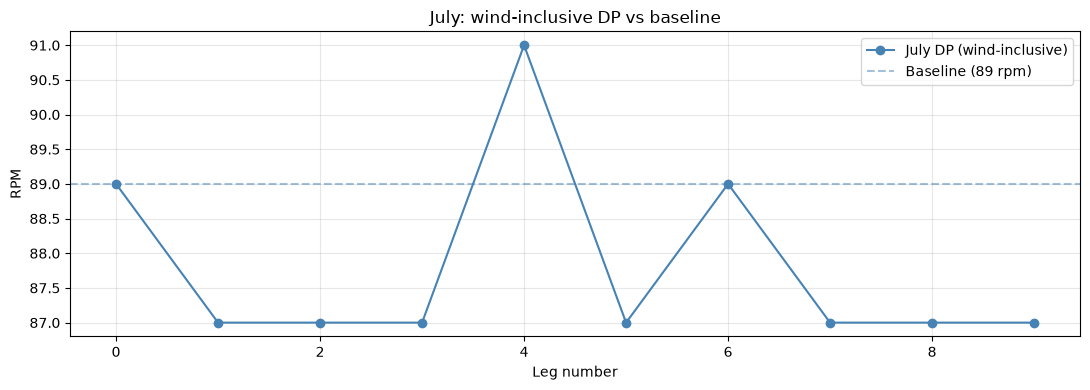

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(jul_wind_legs['leg_id'], jul_wind_legs['dp_rpm'], marker='o', color='steelblue',
        label='July DP (wind-inclusive)')
ax.axhline(jul_wind_legs['baseline_rpm'].iloc[0], color='steelblue', linestyle='--', alpha=0.5,
           label=f"Baseline ({jul_wind_legs['baseline_rpm'].iloc[0]:.0f} rpm)")
ax.set_ylabel('RPM')
ax.set_xlabel('Leg number')
ax.set_title('July: wind-inclusive DP vs baseline')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
from src.models.waves import C_AW_CALIBRATED, TARGET_RATIO_AT_HS3
print(f"Production C_AW_CALIBRATED = {C_AW_CALIBRATED}  (target ratio = {TARGET_RATIO_AT_HS3})")

Production C_AW_CALIBRATED = 3.889  (target ratio = 0.2)


In [13]:
import pandas as pd
from src.config import DEFAULT_ROUTE_ID, DEFAULT_BALLAST_CONDITION
from src.models.ship import SHIP
from src.models.emissions import voyage_cii
from src.data.era5 import load_era5, extract_route_weather
from src.optimizer.leg_cost import build_cost_table
from src.optimizer.dp import run_dp_optimizer, evaluate_month
from src.optimizer.baseline import best_baseline_rpm
from src.database.connection import get_connection, init_db
from src.database.queries import (
    get_route_legs, insert_prediction, insert_prediction_legs, build_dashboard_views,
)

WEATHER_PERIOD = '2025-01'
ROUTE_ID = DEFAULT_ROUTE_ID
BALLAST_CONDITION = DEFAULT_BALLAST_CONDITION
INCLUDE_WIND = True
LOOSENED_DEADLINE_H = 209.64  # from bisection at ratio=0.20, the production C_AW

conn = get_connection()
init_db()

legs = get_route_legs(conn, ROUTE_ID)
weather_df = load_era5()
summary = extract_route_weather(weather_df)
month_period = pd.Period(WEATHER_PERIOD, freq='M')

cost_table = build_cost_table(legs, summary, month_period,
                               include_wind=INCLUDE_WIND,
                               ballast_condition=BALLAST_CONDITION)

policy_df, dp_fuel, dp_time = run_dp_optimizer(cost_table, legs, LOOSENED_DEADLINE_H)
baseline_rpm = best_baseline_rpm(cost_table, legs, LOOSENED_DEADLINE_H)
_, savings_pct = evaluate_month(cost_table, legs, LOOSENED_DEADLINE_H)

is_feasible = pd.notna(dp_fuel)
print(f"Feasible: {is_feasible}  |  dp_fuel_t: {dp_fuel}  |  dp_time_h: {dp_time}  |  savings_pct: {savings_pct}")

baseline_fuel_t = (cost_table[cost_table['rpm'] == baseline_rpm]['fuel_t'].sum()
                    if baseline_rpm is not None else None)

if is_feasible:
    cii_result = voyage_cii(dp_fuel, SHIP['DWT'], legs['dist_nm'].sum())
else:
    cii_result = {'total_co2_t': None, 'attained_cii': None, 'reference_cii': None, 'cii_rating': 'N/A'}

pred_id_jan_wind_loosened = insert_prediction(
    conn, ROUTE_ID, 1, WEATHER_PERIOD, BALLAST_CONDITION, LOOSENED_DEADLINE_H,
    INCLUDE_WIND, dp_fuel if is_feasible else None, baseline_rpm, baseline_fuel_t,
    savings_pct if is_feasible else None, is_feasible,
    total_co2_t=cii_result['total_co2_t'], attained_cii=cii_result['attained_cii'],
    reference_cii=cii_result['reference_cii'], cii_rating=cii_result['cii_rating'],
)

if is_feasible:
    insert_prediction_legs(conn, pred_id_jan_wind_loosened, policy_df)

leg_weather = summary[summary['datetime'] == month_period] if 'datetime' in summary.columns else None
build_dashboard_views(conn, pred_id_jan_wind_loosened, "Rotterdam - New York",
                       "January (harsh, wind-inclusive, loosened deadline)", weather_df=leg_weather)

conn.commit()
conn.close()

print(f"\nInserted prediction_id = {pred_id_jan_wind_loosened}")

Feasible: True  |  dp_fuel_t: 454.03716148184145  |  dp_time_h: 209.60810920744157  |  savings_pct: 0.4526908551819295

Inserted prediction_id = 15


In [14]:
from src.database.connection import get_connection
from src.database.queries import get_dashboard_summary, get_dashboard_legs

conn = get_connection()
jan_wind_summary = get_dashboard_summary(conn, pred_id_jan_wind_loosened)
jul_wind_summary = get_dashboard_summary(conn, pred_id_jul_wind)
jan_wind_legs = get_dashboard_legs(conn, pred_id_jan_wind_loosened)
jul_wind_legs = get_dashboard_legs(conn, pred_id_jul_wind)
conn.close()

print("January (wind-inclusive, loosened deadline) summary:")
print(jan_wind_summary)
print(f"\nJanuary legs rows: {len(jan_wind_legs)}")

January (wind-inclusive, loosened deadline) summary:
{'prediction_id': 15, 'route_id': 'rotterdam_ny', 'route_name': 'Rotterdam - New York', 'weather_period': '2025-01', 'weather_label': 'January (harsh, wind-inclusive, loosened deadline)', 'ballast_condition': 'laden', 'dp_fuel_t': 454.03716148184145, 'baseline_fuel_t': 456.10189304195404, 'savings_pct': 0.4526908551819295, 'savings_label': '0.5% saved', 'is_feasible': 1, 'n_legs': 10, 'total_dist_nm': 3149.4563665493424, 'created_at': '2026-09-06T15:28:34.109868+00:00', 'total_co2_t': 1413.8717208544542, 'attained_cii': 8.211703924659579, 'reference_cii': 7.608216288524462, 'cii_rating': 'D'}

January legs rows: 10


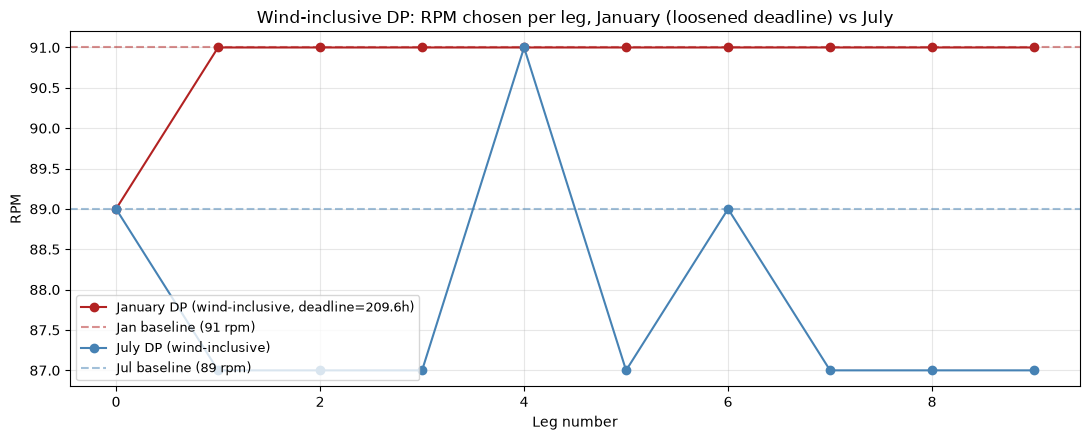


January wind-inclusive fuel: 454.0 t (baseline: 456.1 t, savings: 0.5%)
July wind-inclusive fuel:    372.3 t (baseline: 384.3 t, savings: 3.1%)


In [15]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(jan_wind_legs))

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(x, jan_wind_legs['dp_rpm'], marker='o', color='firebrick',
        label=f"January DP (wind-inclusive, deadline={LOOSENED_DEADLINE_H:.1f}h)")
ax.axhline(jan_wind_legs['baseline_rpm'].iloc[0], color='firebrick', linestyle='--', alpha=0.5,
           label=f"Jan baseline ({jan_wind_legs['baseline_rpm'].iloc[0]:.0f} rpm)")

ax.plot(x[:len(jul_wind_legs)], jul_wind_legs['dp_rpm'], marker='o', color='steelblue',
        label='July DP (wind-inclusive)')
ax.axhline(jul_wind_legs['baseline_rpm'].iloc[0], color='steelblue', linestyle='--', alpha=0.5,
           label=f"Jul baseline ({jul_wind_legs['baseline_rpm'].iloc[0]:.0f} rpm)")

ax.set_ylabel('RPM')
ax.set_xlabel('Leg number')
ax.set_title('Wind-inclusive DP: RPM chosen per leg, January (loosened deadline) vs July')
ax.legend(loc='lower left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nJanuary wind-inclusive fuel: {jan_wind_summary['dp_fuel_t']:.1f} t "
      f"(baseline: {jan_wind_summary['baseline_fuel_t']:.1f} t, savings: {jan_wind_summary['savings_pct']:.1f}%)")
print(f"July wind-inclusive fuel:    {jul_wind_summary['dp_fuel_t']:.1f} t "
      f"(baseline: {jul_wind_summary['baseline_fuel_t']:.1f} t, savings: {jul_wind_summary['savings_pct']:.1f}%)")

In [17]:
conn = get_connection()
row = conn.execute('SELECT deadline_h, weather_period, include_wind FROM voyage_predictions WHERE prediction_id = ?',
                    (pred_id_jan_wind_loosened,)).fetchone()
print(dict(row))
conn.close()

{'deadline_h': 209.64, 'weather_period': '2025-01', 'include_wind': 1}
